## **Instalación e imports básicos**

In [ ]:
!pip install xgboost imbalanced-learn --quiet

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## **Cargar y unificar los CSV**

In [ ]:
# Ajusta los nombres si tus archivos tienen otro nombre
df1 = pd.read_csv("source1.csv")
df2 = pd.read_csv("source2.csv")
df3 = pd.read_csv("source3.csv")

df = pd.concat([df1, df2, df3], ignore_index=True)

print("Shape total:", df.shape)
df.head()


Shape total: (16688, 10)


,video_id,frame_number,activity_label,normalized_leg_length,shoulder_vector_x,shoulder_vector_z,ankle_vector_x,ankle_vector_z,average_hip_angle,average_knee_angle
0,angela1,1,sitting_down,0.625579,-0.787695,0.616065,-0.772279,-0.635284,107.628646,76.536542
1,angela1,2,sitting_down,0.623952,-0.803567,0.595214,-0.769962,-0.638089,107.465999,76.286318
2,angela1,3,sitting_down,0.625596,-0.806423,0.591340,-0.757641,-0.652672,107.788708,76.542410
3,angela1,4,sitting_down,0.629092,-0.806411,0.591355,-0.757460,-0.652882,107.990584,77.050458
4,angela1,5,sitting_down,0.634262,-0.802194,0.597063,-0.770931,-0.636919,108.150790,77.804985


## **Revisión rápida de datos y clases**

In [ ]:
print("Columnas:", df.columns.tolist(), "\n")

print("Info del DataFrame:")
print(df.info(), "\n")

print("Distribución de clases (activity_label):")
print(df["activity_label"].value_counts(), "\n")

print("Ejemplo de filas por video_id:")
print(df.groupby("video_id")["frame_number"].agg(["min", "max", "count"]).head(10))


Columnas: ['video_id', 'frame_number', 'activity_label', 'normalized_leg_length', 'shoulder_vector_x', 'shoulder_vector_z', 'ankle_vector_x', 'ankle_vector_z', 'average_hip_angle', 'average_knee_angle'] 

Info del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16688 entries, 0 to 16687
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   video_id               16688 non-null  object 
 1   frame_number           16688 non-null  int64  
 2   activity_label         16688 non-null  object 
 3   normalized_leg_length  16688 non-null  float64
 4   shoulder_vector_x      16688 non-null  float64
 5   shoulder_vector_z      16688 non-null  float64
 6   ankle_vector_x         16688 non-null  float64
 7   ankle_vector_z         16688 non-null  float64
 8   average_hip_angle      16688 non-null  float64
 9   average_knee_angle     16688 non-null  float64
dtypes: float64(7), int64(1), object(2)
me

In [ ]:
print("=" * 60)
print("INSPECCIÓN INICIAL DEL DATASET")
print("=" * 60)

print(f"\nDimensiones: {df.shape}")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

print("\nInformación del DataFrame:")
df.info()

print("\nPrimeras 10 filas:")
display(df.head(10))

print("\nEstadísticas descriptivas:")
display(df.describe())


INSPECCIÓN INICIAL DEL DATASET

Dimensiones: (16688, 10)
Filas: 16688, Columnas: 10

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16688 entries, 0 to 16687
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   video_id               16688 non-null  object 
 1   frame_number           16688 non-null  int64  
 2   activity_label         16688 non-null  object 
 3   normalized_leg_length  16688 non-null  float64
 4   shoulder_vector_x      16688 non-null  float64
 5   shoulder_vector_z      16688 non-null  float64
 6   ankle_vector_x         16688 non-null  float64
 7   ankle_vector_z         16688 non-null  float64
 8   average_hip_angle      16688 non-null  float64
 9   average_knee_angle     16688 non-null  float64
dtypes: float64(7), int64(1), object(2)
memory usage: 1.3+ MB

Primeras 10 filas:


,video_id,frame_number,activity_label,normalized_leg_length,shoulder_vector_x,shoulder_vector_z,ankle_vector_x,ankle_vector_z,average_hip_angle,average_knee_angle
0,angela1,1,sitting_down,0.625579,-0.787695,0.616065,-0.772279,-0.635284,107.628646,76.536542
1,angela1,2,sitting_down,0.623952,-0.803567,0.595214,-0.769962,-0.638089,107.465999,76.286318
2,angela1,3,sitting_down,0.625596,-0.806423,0.591340,-0.757641,-0.652672,107.788708,76.542410
3,angela1,4,sitting_down,0.629092,-0.806411,0.591355,-0.757460,-0.652882,107.990584,77.050458
4,angela1,5,sitting_down,0.634262,-0.802194,0.597063,-0.770931,-0.636919,108.150790,77.804985
5,angela1,6,sitting_down,0.636340,-0.799426,0.600765,-0.764428,-0.644710,108.418551,78.096468
6,angela1,7,sitting_down,0.636291,-0.800584,0.599221,-0.797038,-0.603929,108.661342,78.085926
7,angela1,8,sitting_down,0.636335,-0.802316,0.596899,-0.851294,-0.524688,109.139763,78.030841
8,angela1,9,sitting_down,0.638521,-0.804963,0.593324,-0.827313,-0.561741,109.069362,78.384546
9,angela1,10,sitting_down,0.639499,-0.804536,0.593904,-0.827605,-0.561311,109.160875,78.533180



Estadísticas descriptivas:


,frame_number,normalized_leg_length,shoulder_vector_x,shoulder_vector_z,ankle_vector_x,ankle_vector_z,average_hip_angle,average_knee_angle
count,16688.000000,16688.000000,16688.000000,16688.000000,16688.000000,16688.000000,16688.000000,16688.000000
mean,394.189837,0.931275,-0.737831,0.535312,-0.434020,-0.034152,153.333815,145.035289
std,318.005510,0.095169,0.209089,0.354032,0.503515,0.746312,23.663399,24.943797
min,0.000000,0.567397,-1.000000,-0.997513,-1.000000,-1.000000,62.553845,67.352127
25%,147.000000,0.941821,-0.879780,0.445171,-0.862050,-0.800785,156.803970,141.998105
50%,315.000000,0.968774,-0.785849,0.602354,-0.577172,-0.082292,163.769765,152.129799
75%,569.250000,0.982691,-0.664818,0.725383,-0.103918,0.743990,166.538267,159.488091
max,1583.000000,0.999507,0.858344,0.999984,1.000000,1.000000,176.900008,176.494372


# **Análisis Exploratorio de Datos (EDA)**

En esta sección, realizaremos un análisis detallado de las variables para entender sus distribuciones, relaciones y cómo se comportan a lo largo del tiempo en las secuencias de video. El objetivo es obtener insights que validen nuestras decisiones de modelado.

## **2.1. Análisis de la Variable Objetivo: `activity_label`**

Comenzamos analizando la distribución de la variable que queremos predecir. Un desbalance significativo entre las clases puede afectar el rendimiento del modelo, haciendo que se incline a predecir las clases mayoritarias.

/tmp/ipython-input-3770787065.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['activity_label'], order=df['activity_label'].value_counts().index, palette='viridis')


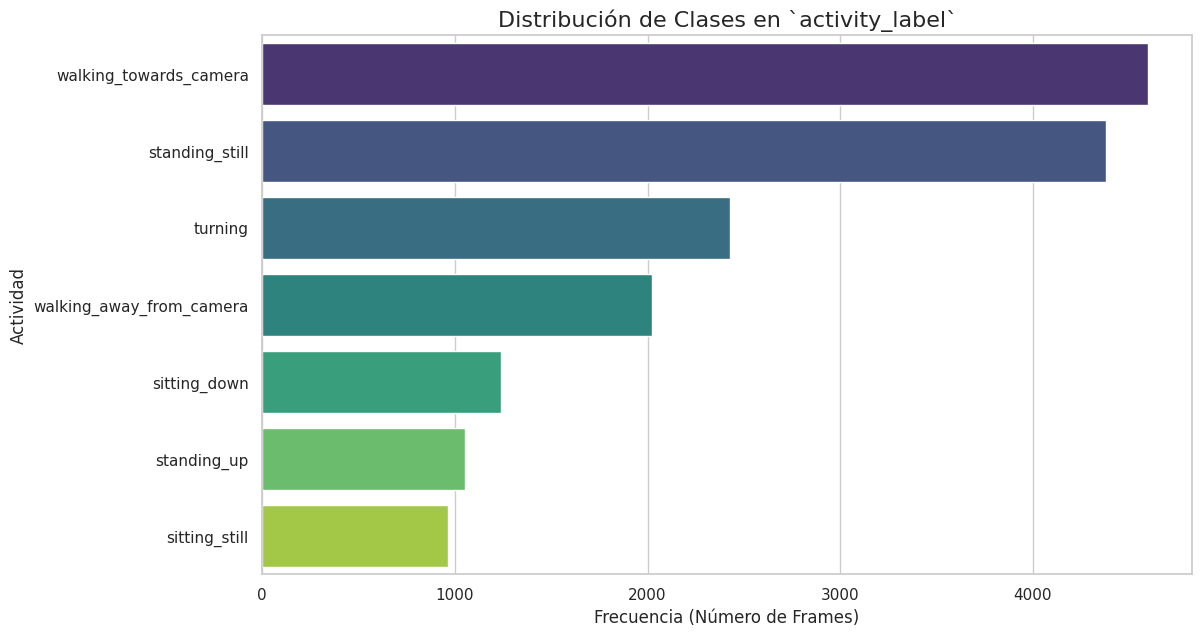

In [ ]:
# Configuración de estilo para los gráficos
sns.set(style="whitegrid")

# Gráfico de distribución de la variable objetivo
plt.figure(figsize=(12, 7))
sns.countplot(y=df['activity_label'], order=df['activity_label'].value_counts().index, palette='viridis')
plt.title('Distribución de Clases en `activity_label`', fontsize=16)
plt.xlabel('Frecuencia (Número de Frames)', fontsize=12)
plt.ylabel('Actividad', fontsize=12)
plt.show()


Este gráfico revela la frecuencia de cada actividad en el conjunto de datos, medida en número de frames.

#### **Observaciones Clave:**

*   **Desbalance de Clases:** La observación más importante es el fuerte desbalance entre las clases. Las actividades `walking_towards_camera` y `standing_still` dominan el dataset, mientras que `sitting_still` y `standing_up` son significativamente menos frecuentes.
*   **Magnitud:** La clase mayoritaria es más de cuatro veces más frecuente que la minoritaria.

#### **Implicaciones y Consideraciones a Futuro:**

1.  **Riesgo de Sesgo:** Un modelo entrenado con estos datos desbalanceados podría aprender a predecir muy bien las clases comunes, pero fallar en identificar correctamente las actividades menos frecuentes, lo que limitaría su utilidad práctica.
2.  **Estrategias de Mitigación:** Este hallazgo sugiere que será necesario considerar estrategias para manejar el desbalance. Opciones a explorar incluyen técnicas de remuestreo para el conjunto de entrenamiento (como sobremuestrear las clases minoritarias) para asegurar que el modelo aprenda de todas las actividades por igual.
3.  **Evaluación del Modelo:** La métrica de exactitud (accuracy) por sí sola no será suficiente para evaluar el modelo. Será crucial analizar métricas por clase (como precisión y recall) para verificar que el modelo es efectivo en la detección de todas las actividades, incluyendo las minoritarias.

## **2.2. Análisis Univariado de Features Numéricas**

Estudiamos la distribución de cada una de las 7 features para identificar su rango de valores, tendencia central y dispersión. Usaremos histogramas para ver la forma de la distribución y boxplots para detectar valores atípicos.

Distribución y Boxplots de las Features Numéricas:


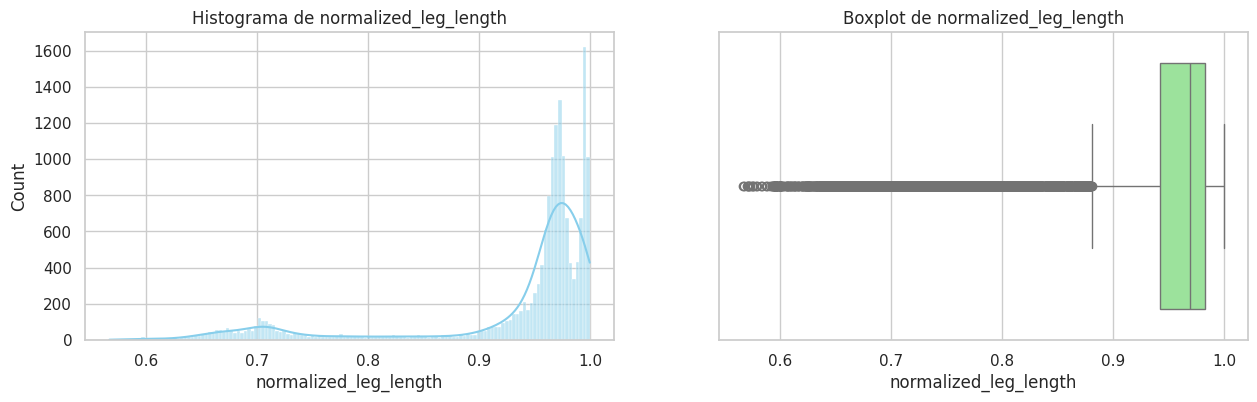

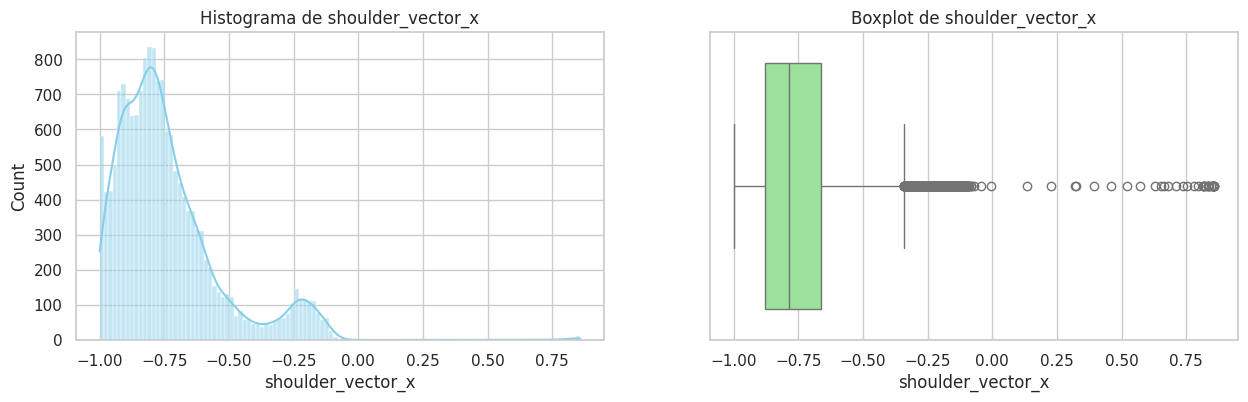

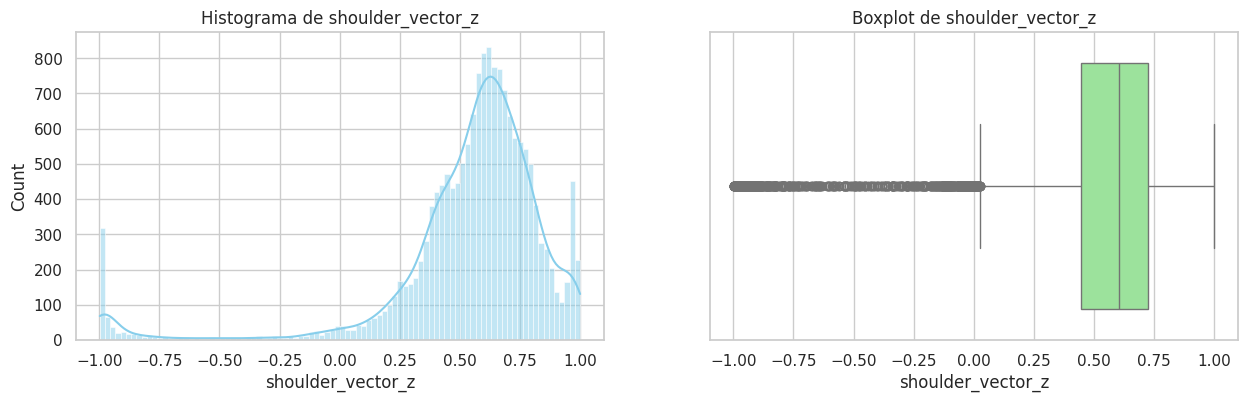

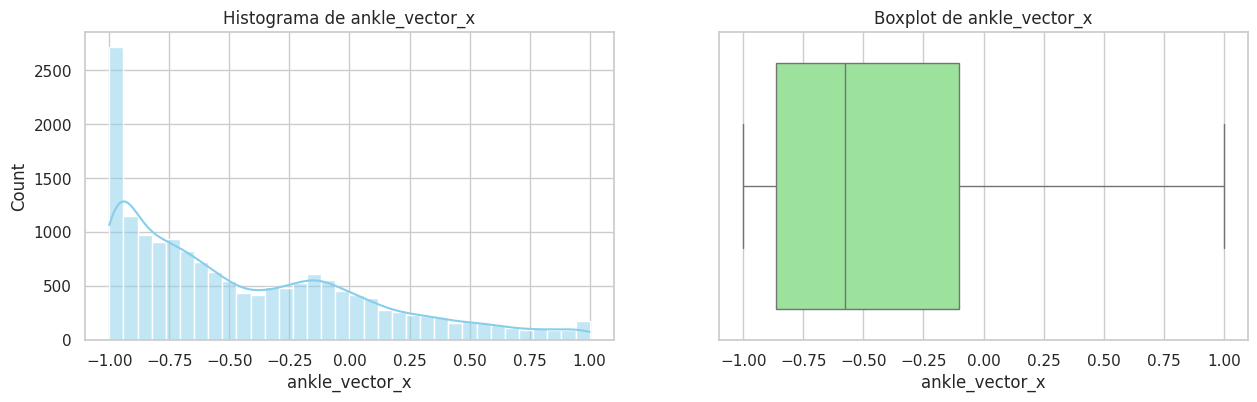

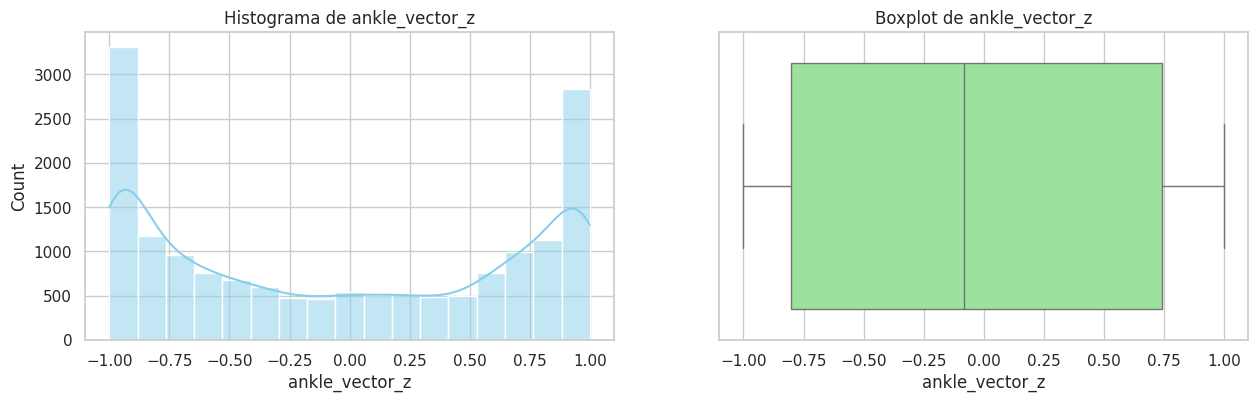

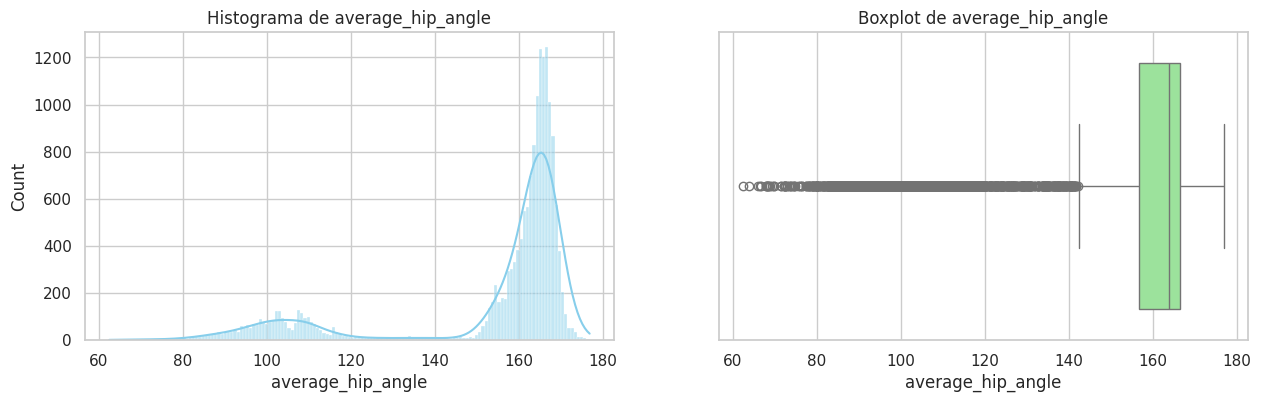

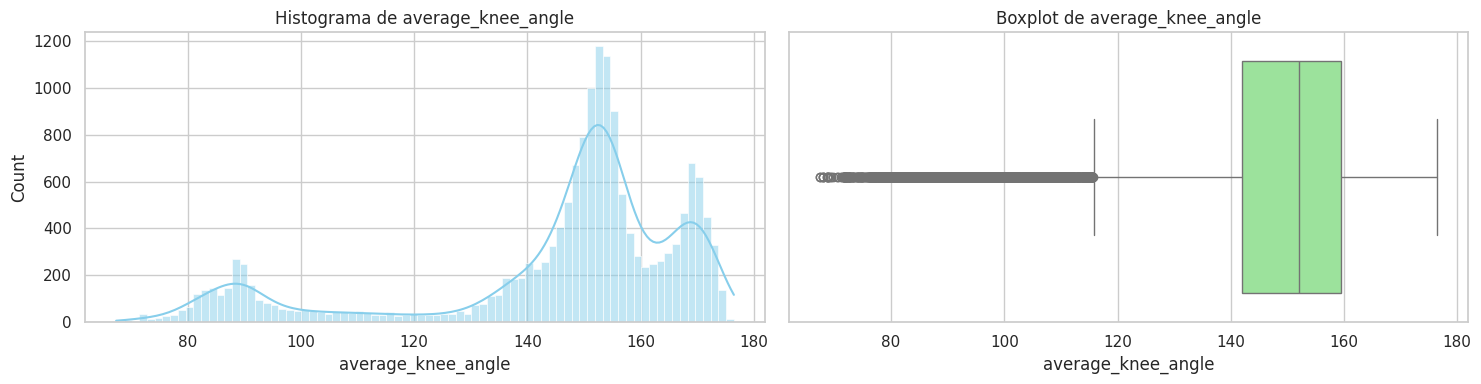

In [ ]:
non_feature_cols = ["video_id", "frame_number", "activity_label"]
feature_cols = [c for c in df.columns if c not in non_feature_cols]
print("Distribución y Boxplots de las Features Numéricas:")
for col in feature_cols:
  fig, axes = plt.subplots(1, 2, figsize=(15, 4))
  # Histograma
  sns.histplot(df[col], kde=True, ax=axes[0], color='skyblue')
  axes[0].set_title(f'Histograma de {col}')

  # Boxplot
  sns.boxplot(x=df[col], ax=axes[1], color='lightgreen')
  axes[1].set_title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

#### **Análisis por Feature:**

1.  **`normalized_leg_length` (Longitud Normalizada de la Pierna):**
    *   **Histograma:** La distribución está fuertemente **sesgada a la derecha**, con una concentración masiva de valores muy cercanos a 1.0. Esto tiene sentido físico: un valor de 1.0 representa una pierna completamente estirada, lo cual ocurre en actividades comunes como `standing_still` y `walking`. Hay un pico mucho menor alrededor de 0.6-0.7, que probablemente corresponde a actividades donde las piernas están flexionadas, como `sitting_down`.
    *   **Boxplot:** Confirma el sesgo. La "caja" (el 50% central de los datos) está comprimida en el extremo superior. Los puntos a la izquierda son marcados como "atípicos", pero en este contexto, no son errores, sino **representaciones válidas de la actividad de sentarse**, que es menos frecuente.

2.  **`shoulder_vector_x` y `shoulder_vector_z` (Vectores de Hombro):**
    *   **Histograma:** Ambas distribuciones están muy sesgadas. `shoulder_vector_x` tiene su pico principal en valores negativos (cerca de -0.8), mientras que `shoulder_vector_z` lo tiene en valores positivos (cerca de 0.7). Esto sugiere que hay una orientación predominante de los hombros de los sujetos con respecto a la cámara en la mayoría de los videos.
    *   **Boxplot:** Los boxplots muestran estas concentraciones y una larga cola de "valores atípicos" en la dirección opuesta. Nuevamente, estos no son errores, sino que probablemente representan otras orientaciones corporales, como durante la actividad de `turning` (girando).

3.  **`ankle_vector_x` y `ankle_vector_z` (Vectores de Tobillo):**
    *   **Histograma:** Estas distribuciones son muy interesantes. `ankle_vector_x` es bimodal, con un pico fuerte cerca de -1.0. Aún más revelador es `ankle_vector_z`, que tiene una **distribución en forma de "U"**, con picos en los extremos -1.0 y +1.0. Esto indica que los tobillos se encuentran mayormente apuntando directamente hacia la cámara (ej. `walking_towards_camera`) o en dirección opuesta (`walking_away_from_camera`). Los valores intermedios son menos comunes.
    *   **Boxplot:** Las cajas son anchas, lo que indica una gran variabilidad en estas features, haciéndolas potencialmente muy útiles para distinguir entre diferentes movimientos.

4.  **`average_hip_angle` y `average_knee_angle` (Ángulos Promedio de Cadera y Rodilla):**
    *   **Histograma:** Ambas variables muestran una clara **distribución bimodal**. Hay un pico muy grande y definido en ángulos altos (150-170 grados), que corresponde a estar de pie o caminar (piernas extendidas). Hay un segundo pico, más pequeño, en ángulos bajos (alrededor de 90-110 grados), que corresponde inequívocamente a la acción de estar sentado.
    *   **Boxplot:** Al igual que con `normalized_leg_length`, la mayoría de los datos se concentran en valores altos, y los valores más bajos (que representan el acto de sentarse) aparecen como una larga cola de "atípicos".

#### **Conclusiones Generales e Implicaciones:**

1.  **Distribuciones No Normales:** Ninguna de las features sigue una distribución normal (gaussiana). La mayoría son bimodales o fuertemente sesgadas. Esto es una **excelente noticia**, ya que indica que las features capturan de forma natural los distintos estados físicos del cuerpo (ej. sentado vs. de pie).

2.  **Diferencia de Escalas:** Se confirma una diferencia significativa en las escalas de las variables. Los vectores están en el rango [-1, 1], mientras que los ángulos están en un rango mucho mayor [~60, ~180]. Esto hace que el **escalado de características** (como el uso de `StandardScaler` más adelante) sea un paso **absolutamente necesario** para que el modelo no asigne una importancia indebida a las variables con rangos numéricos más grandes.

3.  **Los "Outliers" son Informativos:** Los valores atípicos detectados por los boxplots no son ruido ni errores de medición. Representan las clases minoritarias (como sentarse) y son cruciales para el problema. **No deben ser eliminados**.

4.  **Potencial Predictivo:** Todas las features muestran estructuras y variaciones claras, lo que sugiere que todas son potencialmente valiosas para que el modelo de clasificación pueda distinguir entre las diferentes actividades.

### **Paso 4: Análisis Bivariado (Features vs. Variable Objetivo)**

Este es uno de los pasos más importantes. Queremos ver si las distribuciones de las features cambian para cada actividad. Si una feature se ve muy diferente entre dos actividades, es una buena señal de que será útil para que el modelo las distinga.

## **2.3. Análisis Bivariado: Features vs. `activity_label`**

Ahora, exploramos cómo se relaciona cada feature con la actividad que se está realizando. Si la distribución de una feature varía significativamente entre las diferentes clases, es un buen indicador de que es una variable predictiva importante.

Distribución de Features por Actividad:


/tmp/ipython-input-3586793193.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='activity_label', x=col, data=df, palette='viridis', orient='h')


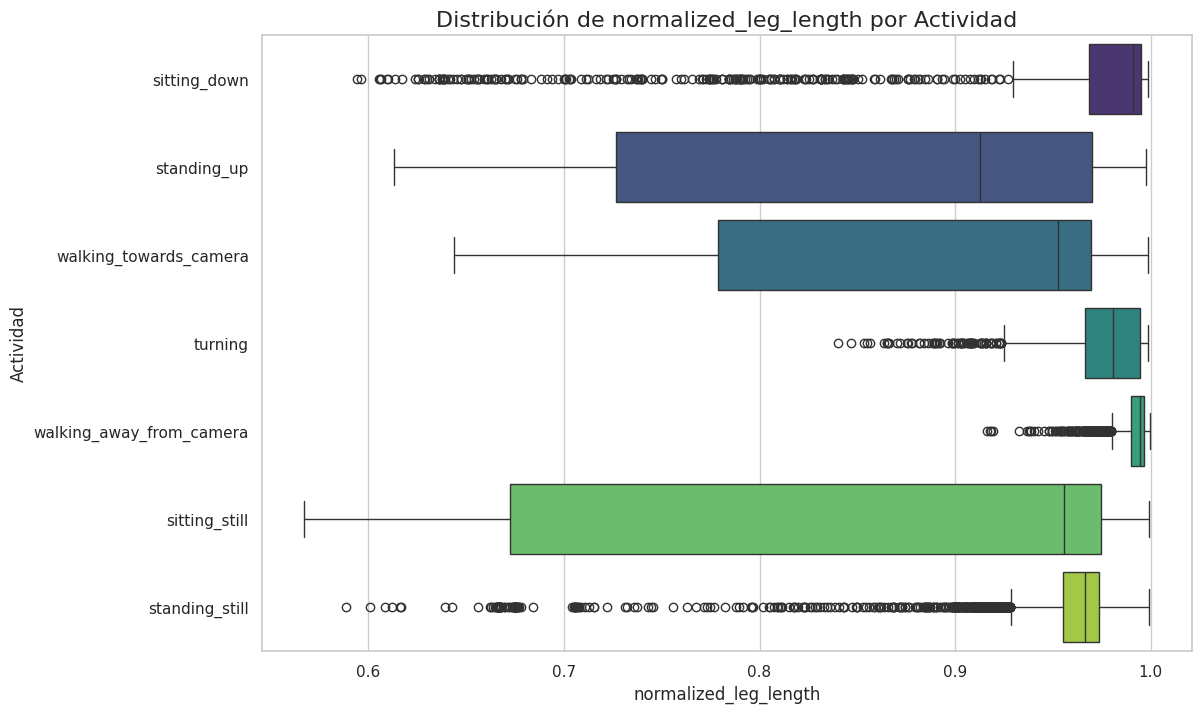

/tmp/ipython-input-3586793193.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='activity_label', x=col, data=df, palette='viridis', orient='h')


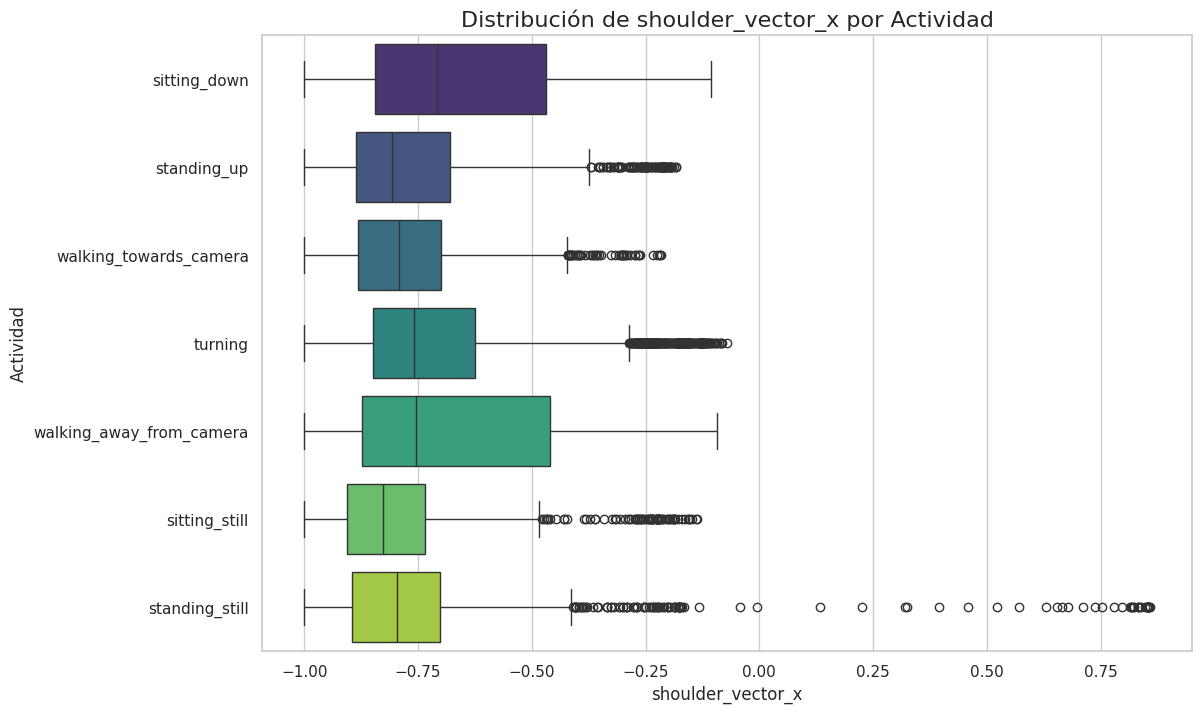

/tmp/ipython-input-3586793193.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='activity_label', x=col, data=df, palette='viridis', orient='h')


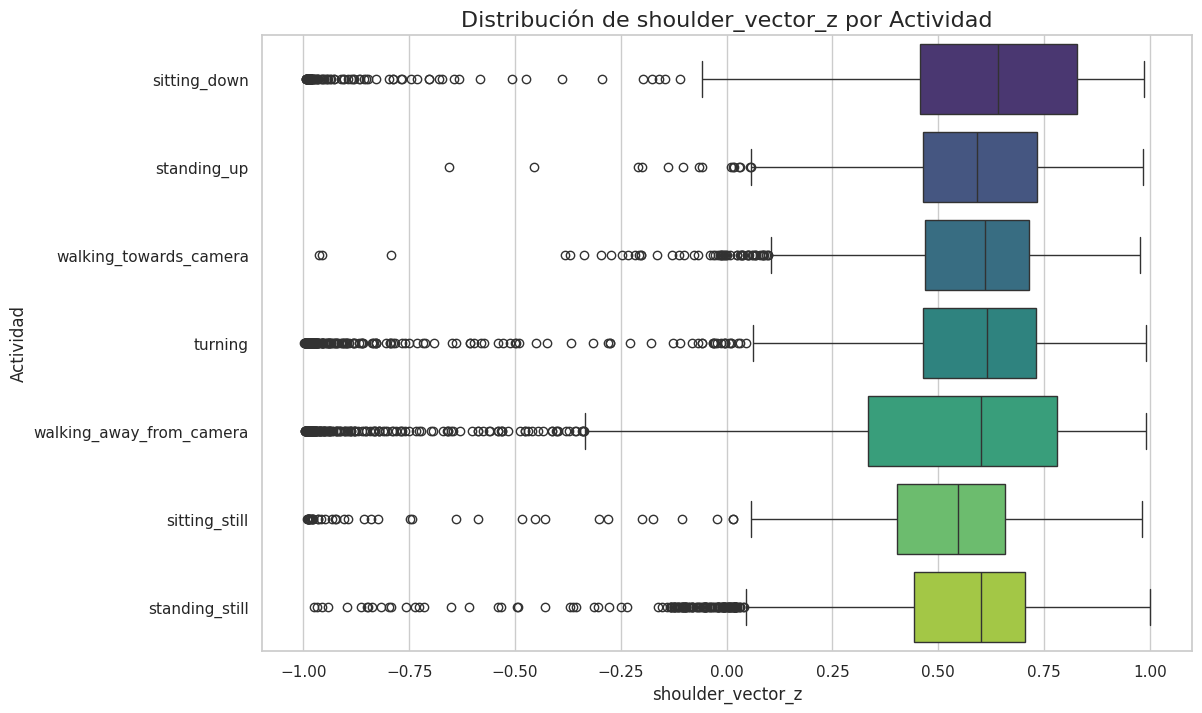

/tmp/ipython-input-3586793193.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='activity_label', x=col, data=df, palette='viridis', orient='h')


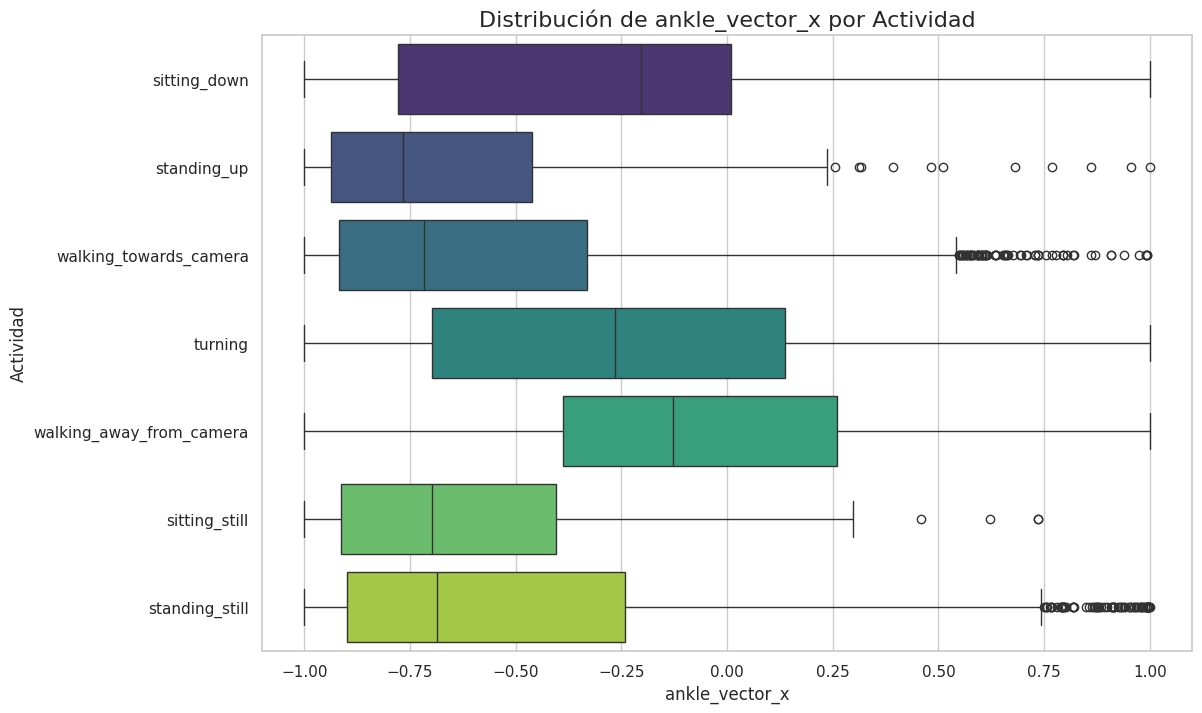

/tmp/ipython-input-3586793193.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='activity_label', x=col, data=df, palette='viridis', orient='h')


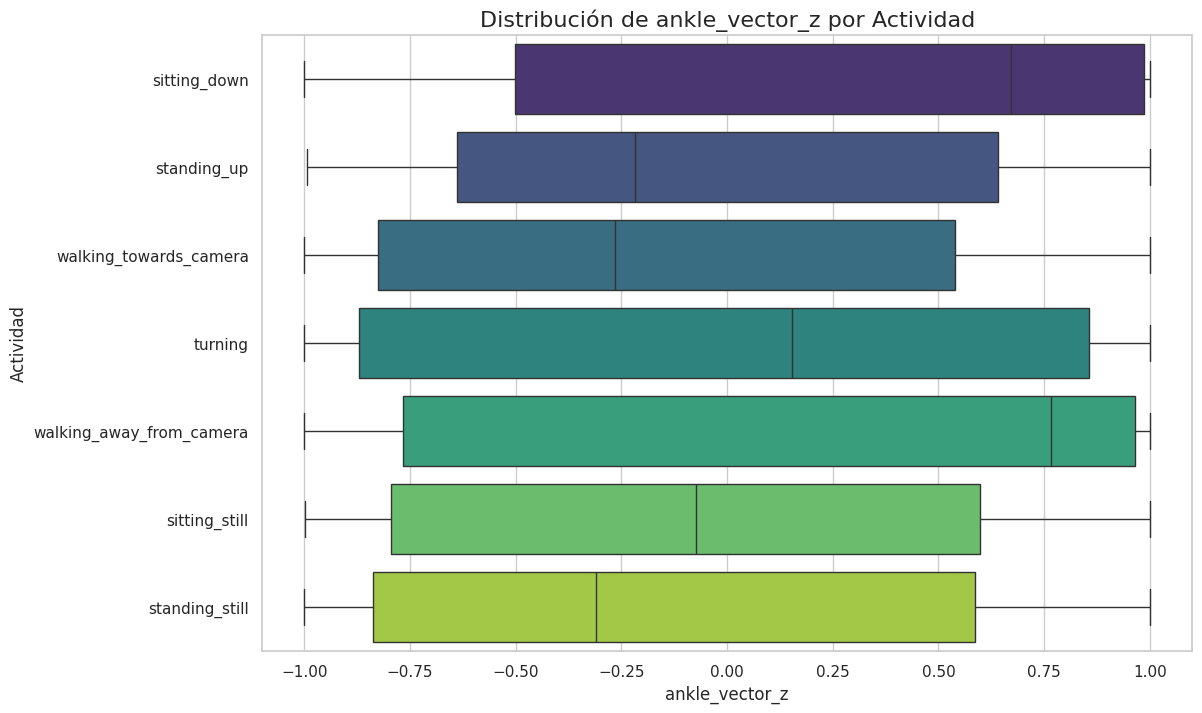

/tmp/ipython-input-3586793193.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='activity_label', x=col, data=df, palette='viridis', orient='h')


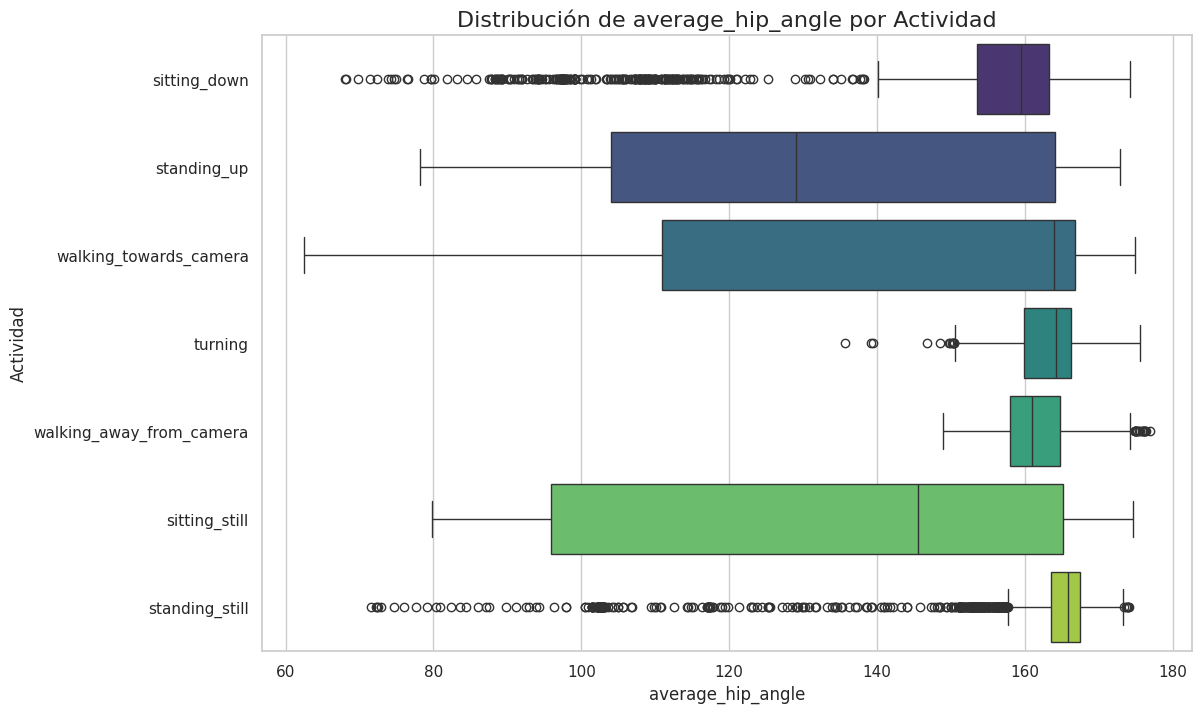

/tmp/ipython-input-3586793193.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='activity_label', x=col, data=df, palette='viridis', orient='h')


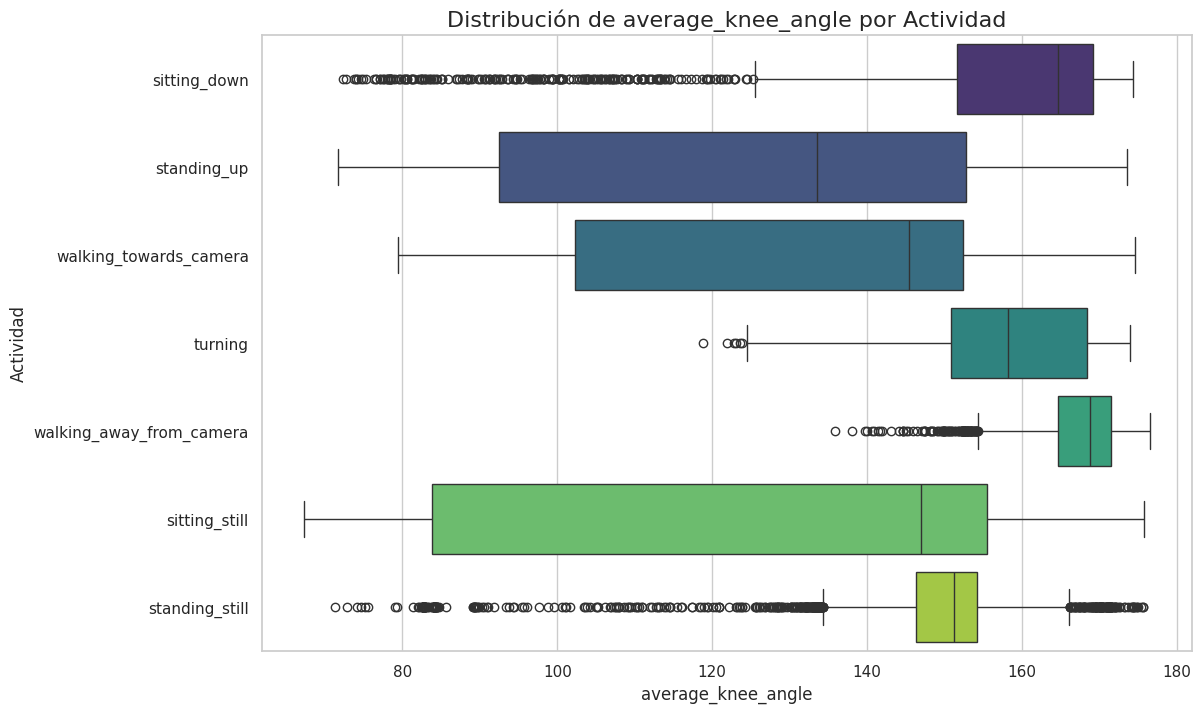

In [ ]:
# Crear boxplots de cada feature agrupada por activity_label
print("Distribución de Features por Actividad:")
for col in feature_cols:
    plt.figure(figsize=(12, 8))
    sns.boxplot(y='activity_label', x=col, data=df, palette='viridis', orient='h')
    plt.title(f'Distribución de {col} por Actividad', fontsize=16)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Actividad', fontsize=12)
    plt.show()



Estos boxplots son extremadamente informativos. Nos muestran cómo la distribución de cada feature cambia a través de las diferentes actividades. El objetivo es buscar patrones claros y separaciones entre las "cajas", ya que esto indica que la feature es útil para distinguir una actividad de otra.

#### **Observaciones Clave por Feature:**

1.  **`average_knee_angle` y `average_hip_angle` (Los más Predictivos):**
    *   **Observación:** Estas dos features son las estrellas del análisis. Muestran una **separación casi perfecta** entre dos grupos de actividades:
        *   **Ángulos Bajos (Articulaciones Flexionadas):** La actividad `sitting_still` (sentado quieto) tiene consistentemente ángulos bajos y un rango muy estrecho, como es de esperar.
        *   **Ángulos Altos (Articulaciones Extendidas):** Las actividades `walking...` (caminando) y `standing_still` (de pie quieto) tienen ángulos altos, cercanos a los 180 grados.
    *   **Actividades de Transición:** `sitting_down` (sentándose) y `standing_up` (levantándose) muestran una **variabilidad mucho mayor** (cajas más grandes), lo cual es lógico, ya que durante estas acciones los ángulos de las rodillas y caderas están en pleno movimiento, pasando de extendidos a flexionados o viceversa.
    *   **Implicación:** Estas dos variables por sí solas son extremadamente potentes para que el modelo pueda diferenciar entre estar sentado, estar de pie y las transiciones entre ambos estados.

2.  **`normalized_leg_length` (Longitud Normalizada de la Pierna):**
    *   **Observación:** Sigue un patrón muy similar al de los ángulos. Los valores son bajos para `sitting_still` (cuerpo "comprimido") y altos (cercanos a 1.0) para `walking...` y `standing_still` (cuerpo erguido).
    *   **Implicación:** Confirma que esta feature es altamente predictiva y captura una información similar a la de los ángulos, actuando como un excelente indicador de la postura vertical general de la persona.

3.  **`ankle_vector_z` y `shoulder_vector_z` (Vectores de Profundidad):**
    *   **Observación:** Estas features son clave para distinguir la **direccionalidad del movimiento**. Por ejemplo, en `ankle_vector_z`, la actividad `walking_away_from_camera` tiene una distribución de valores claramente positiva, mientras que `walking_towards_camera` tiende a tener valores más bajos o negativos.
    *   **Implicación:** Mientras que los ángulos nos dicen *qué* está haciendo la persona (sentarse, caminar), los vectores 'z' le dicen al modelo *hacia dónde* se está moviendo con respecto a la cámara. Son fundamentales para diferenciar entre caminar hacia la cámara y alejarse de ella.

4.  **`ankle_vector_x` y `shoulder_vector_x` (Vectores Laterales):**
    *   **Observación:** Muestran cierta separación entre clases, aunque menos dramática que las otras features. Por ejemplo, en `shoulder_vector_x`, la mayoría de las actividades tienen una mediana en valores negativos, lo que sugiere una postura corporal consistente en relación con el eje X de la cámara.
    *   **Implicación:** Aunque quizás no sean las features más fuertes, aportan información sobre la orientación lateral del cuerpo que, en combinación con las otras, ayudará al modelo a afinar sus predicciones, especialmente para actividades como `turning` (girando).

#### **Conclusiones Generales e Implicaciones para el Modelo:**

*   **Alto Poder Predictivo:** El análisis confirma que las features seleccionadas son **altamente relevantes** para el problema. Cada una de ellas muestra patrones distintos y lógicos para las diferentes actividades.
*   **Sinergia entre Features:** Ninguna feature por sí sola puede resolver todo el problema, pero juntas son muy poderosas. Los ángulos separan las posturas (sentado/de pie), y los vectores de profundidad (`_z`) separan la dirección del movimiento. Esta complementariedad es exactamente lo que un modelo de machine learning necesita para tener éxito.
*   **Confianza en el Enfoque:** Este análisis nos da una gran confianza en que un modelo de clasificación, al observar una secuencia de estos valores, tendrá la información necesaria para realizar predicciones precisas. Las diferencias visuales en estas distribuciones son la base sobre la cual el algoritmo de XGBoost construirá sus reglas de decisión.

## **2.4. Matriz de Correlación de Features**

Analizamos la correlación lineal entre las features numéricas. Una correlación alta (cercana a 1 o -1) entre dos variables indica que contienen información similar.

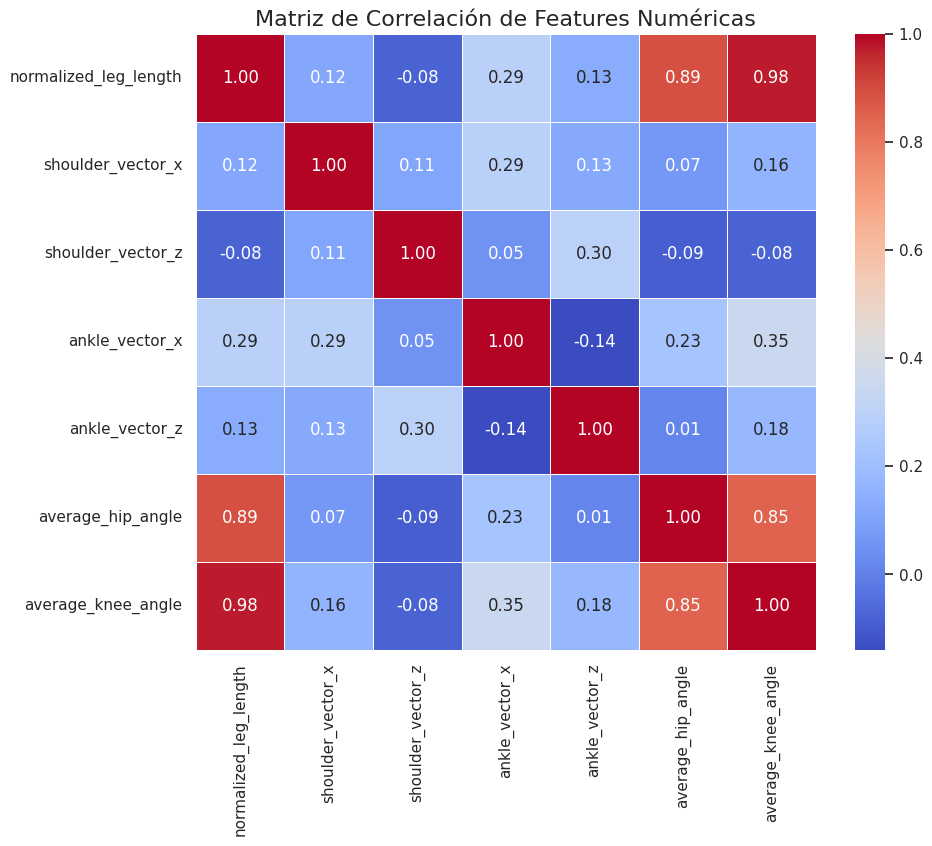

In [ ]:
# Calcular la matriz de correlación
correlation_matrix = df[feature_cols].corr()

# Visualizar la matriz de correlación con un heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlación de Features Numéricas', fontsize=16)
plt.show()

#### **Observaciones Clave:**

1.  **Correlación Positiva Muy Fuerte (Redundancia de Información):**
    *   **`average_knee_angle` y `normalized_leg_length` (0.98):** Esta es la correlación más fuerte del gráfico. Es casi perfecta (1.0). Esto es completamente lógico: a medida que el ángulo de la rodilla se extiende (se acerca a 180°), la longitud normalizada de la pierna se acerca a 1.0 (totalmente estirada). Ambas variables están midiendo, en esencia, el mismo fenómeno físico: qué tan estirada está la pierna.
    *   **`average_hip_angle` y `average_knee_angle` (0.85):** También hay una fuerte correlación positiva aquí. Generalmente, cuando las rodillas están extendidas (caminando/de pie), la cadera también lo está.
    *   **`average_hip_angle` y `normalized_leg_length` (0.89):** Similar al primer punto, una cadera extendida implica una postura erguida, lo que se correlaciona con una mayor longitud de pierna normalizada.

2.  **Correlaciones Moderadas y Bajas:**
    *   La mayoría de los otros pares de variables muestran **correlaciones débiles o muy bajas** (valores entre -0.3 y 0.3). Por ejemplo, los vectores de los hombros (`shoulder_vector_x`, `_z`) tienen muy poca relación lineal con los ángulos de las piernas.
    *   Esto es una **buena noticia**, ya que significa que estas otras features (los vectores) están aportando **información única y complementaria** que no está capturada por los ángulos o la longitud de la pierna.

#### **Implicaciones para el Modelo:**

*   **Multicolinealidad:** La alta correlación entre los ángulos y la longitud de la pierna indica la presencia de **multicolinealidad**. Esto significa que algunas de las features son linealmente predecibles a partir de otras.
    *   Para modelos lineales (como la regresión logística), esto podría ser un problema.
    *   Sin embargo, para los **modelos basados en árboles como XGBoost**, la multicolinealidad **no es un problema grave**. El algoritmo selecciona la feature que mejor divide los datos en cada nodo, y si dos features tienen información similar, simplemente elegirá una de ellas y le dará menos importancia a la otra. No afectará negativamente el rendimiento predictivo del modelo.



#### **En Resumen:**

La matriz de correlación confirma las relaciones físicas esperadas entre las articulaciones de las piernas y la postura general. Revela una alta redundancia entre los ángulos y la longitud de la pierna, pero también muestra que los vectores de orientación corporal aportan información independiente. Aunque existe multicolinealidad, no es un impedimento para el modelo XGBoost seleccionado, por lo que podemos proceder con todas las features con confianza.

## **2.5. Análisis de Series Temporales**

Finalmente, dado que los datos son secuencias de frames de video, es crucial visualizar cómo evolucionan las features a lo largo del tiempo. Esto nos ayudará a entender los patrones dinámicos de cada actividad y a validar la lógica de usar ventanas de frames para la clasificación.

Evolución de Features a lo largo del tiempo para videos de ejemplo:


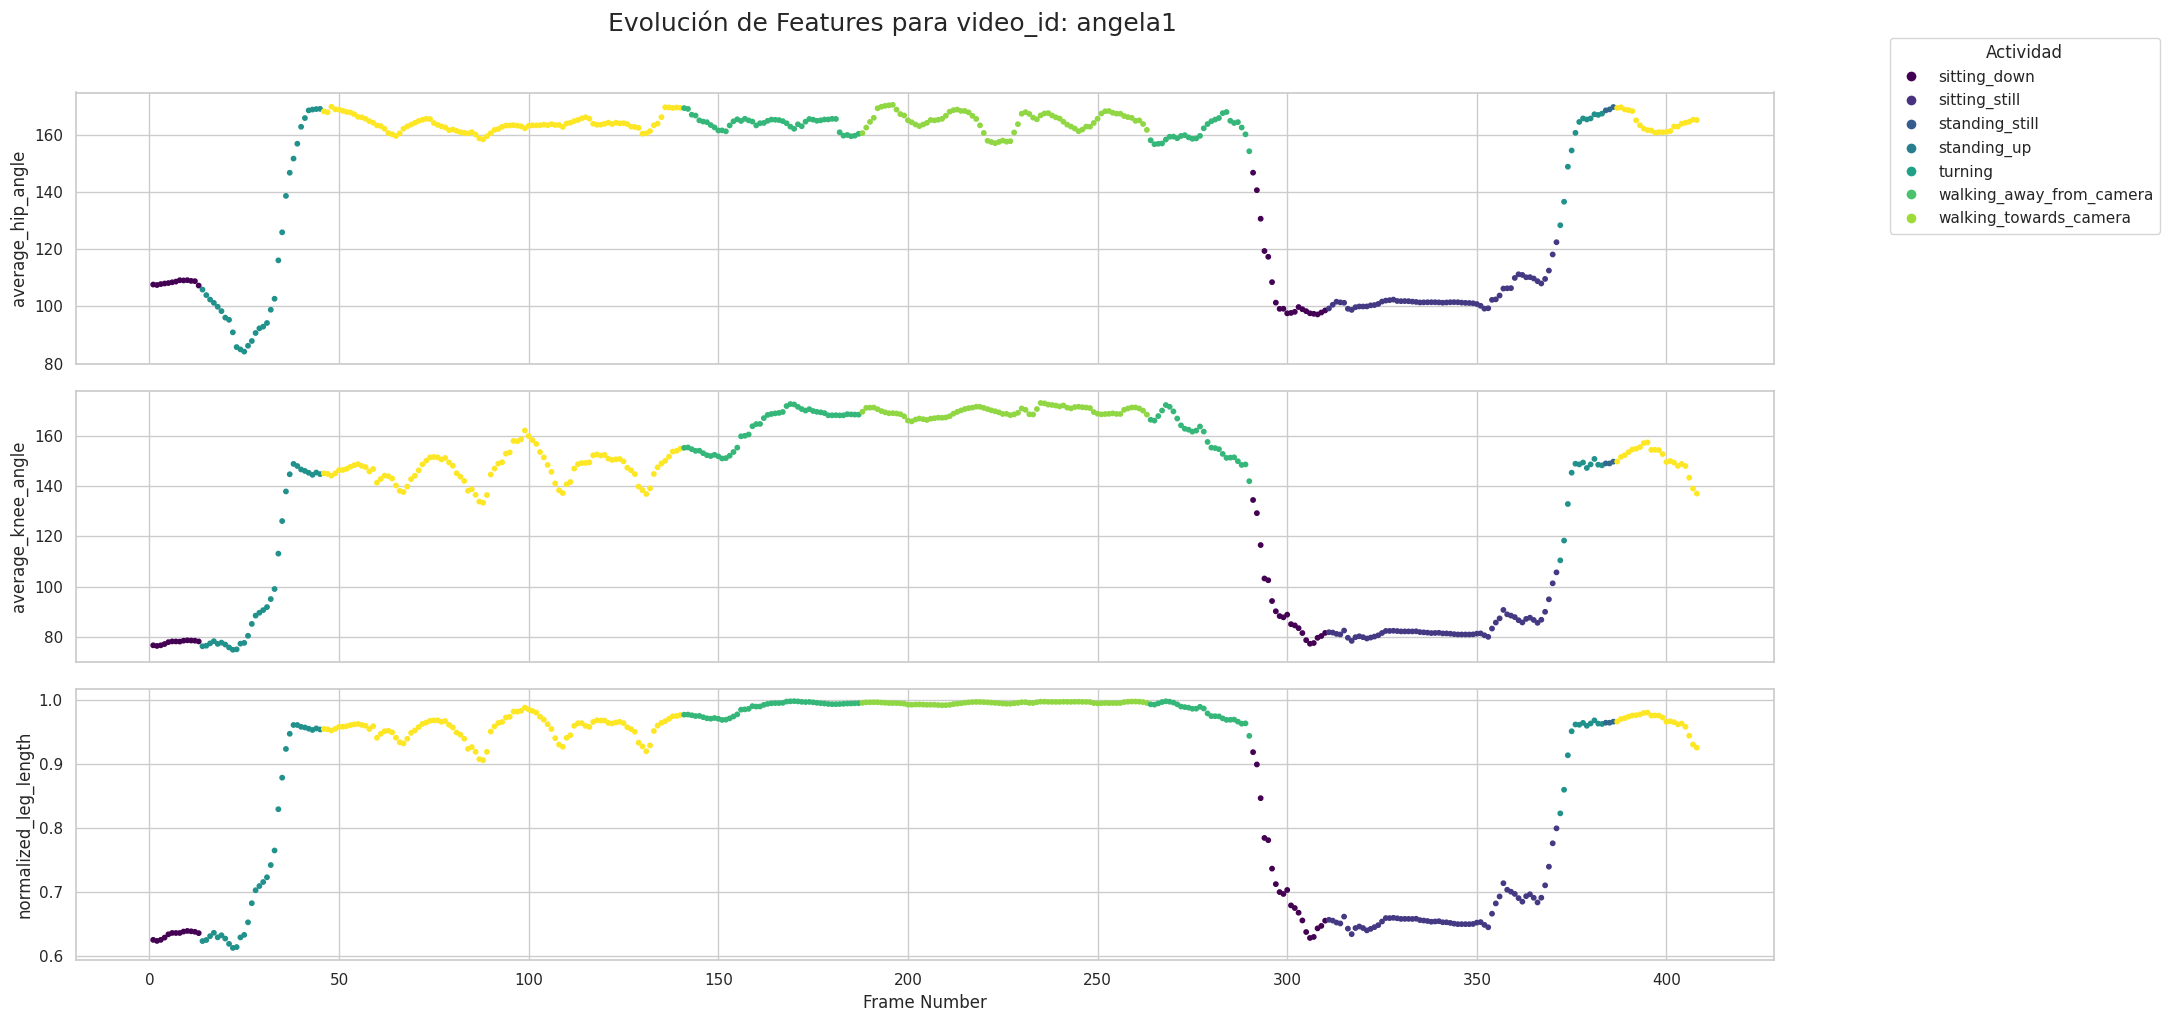

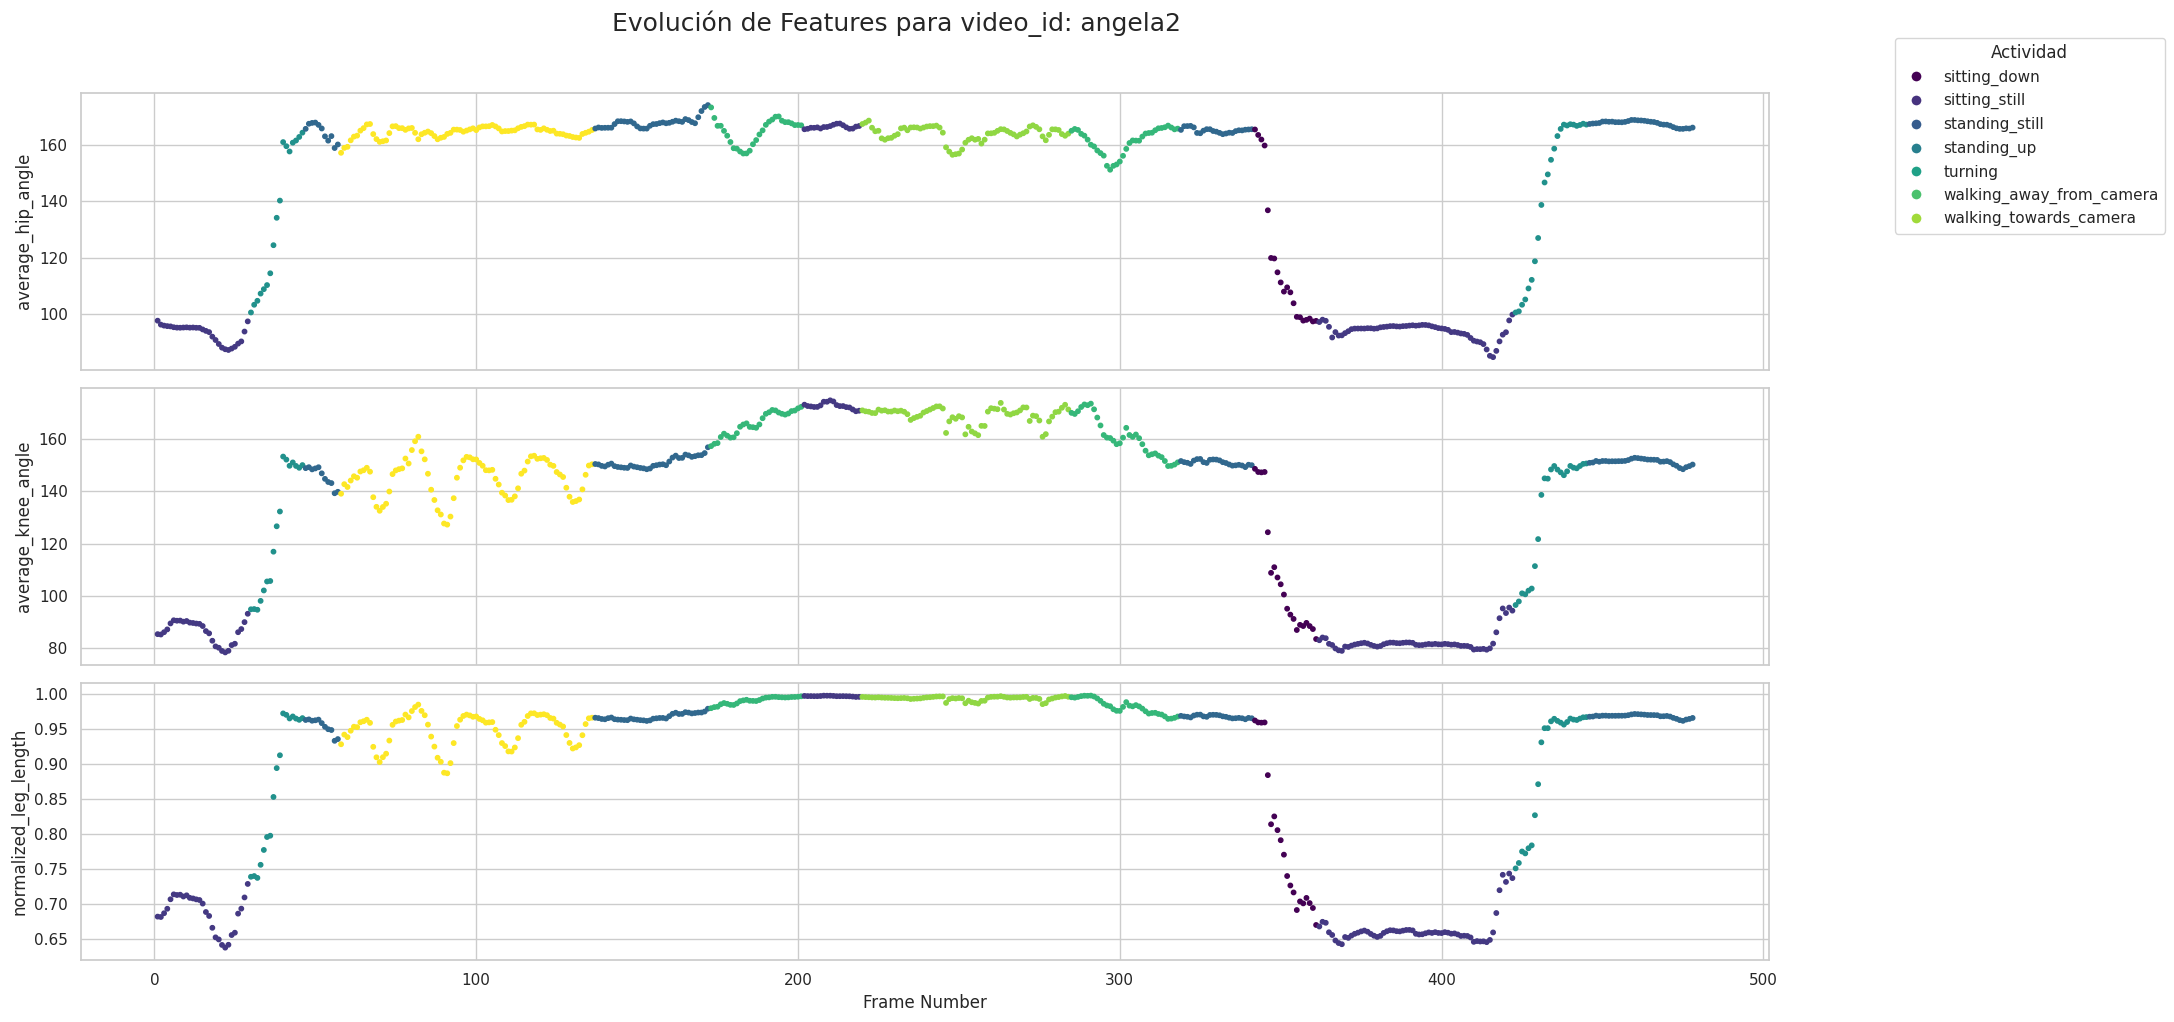

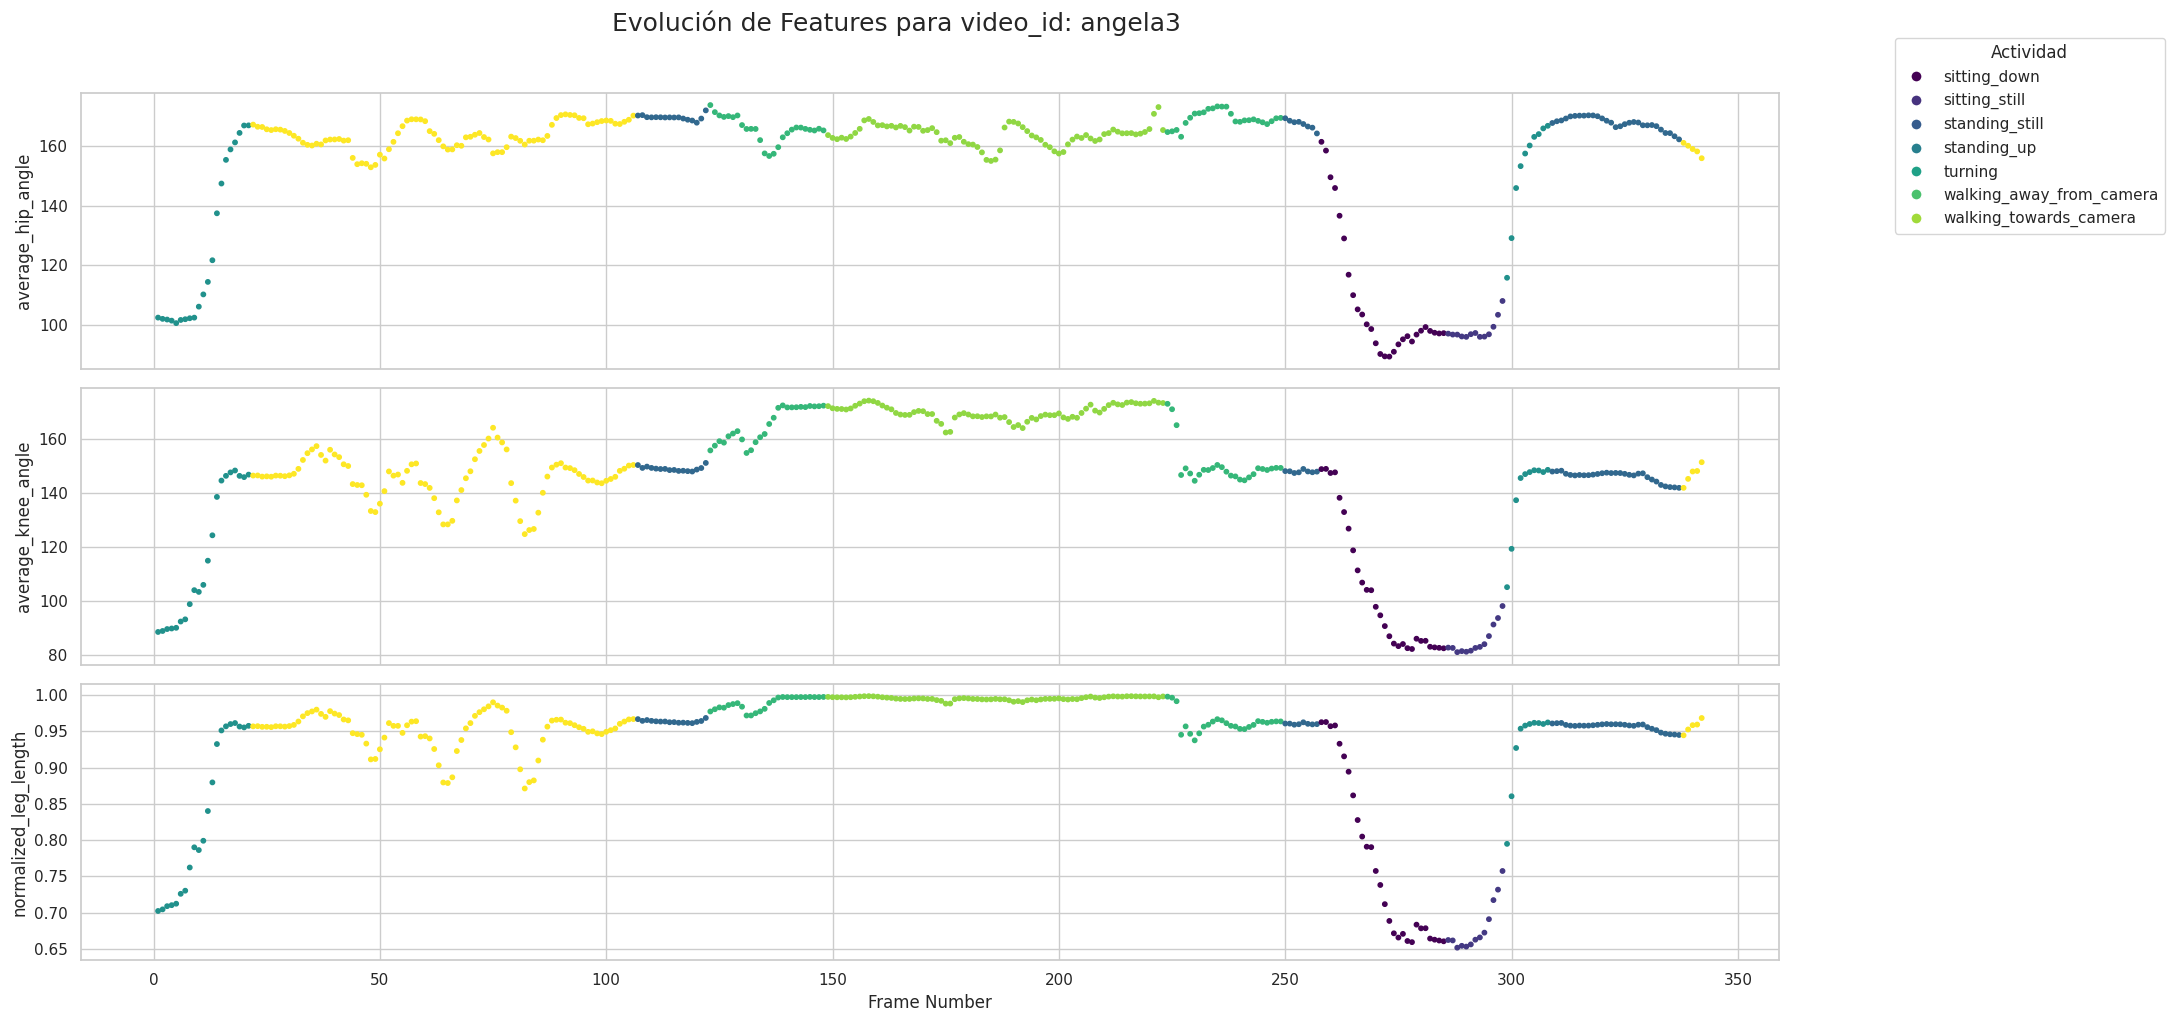

In [ ]:
# Seleccionamos algunos videos de ejemplo para visualizar
video_ids_ejemplo = df['video_id'].unique()[:3] # Tomamos los primeros 3 videos

# Mapeamos las etiquetas a números para poder colorear los gráficos
le_temp = LabelEncoder()
df['activity_label_encoded'] = le_temp.fit_transform(df['activity_label'])
label_mapping = {i: label for i, label in enumerate(le_temp.classes_)}

print("Evolución de Features a lo largo del tiempo para videos de ejemplo:")
for video_id in video_ids_ejemplo:
    df_video = df[df['video_id'] == video_id].sort_values('frame_number')

    # Graficamos solo algunas de las features más interesantes (ej. los ángulos)
    features_a_graficar = ['average_hip_angle', 'average_knee_angle', 'normalized_leg_length']

    fig, axes = plt.subplots(len(features_a_graficar), 1, figsize=(18, 10), sharex=True)
    fig.suptitle(f'Evolución de Features para video_id: {video_id}', fontsize=18, y=1.02)

    for i, col in enumerate(features_a_graficar):
        # Usamos scatter plot y coloreamos por actividad
        scatter = axes[i].scatter(df_video['frame_number'], df_video[col],
                                  c=df_video['activity_label_encoded'],
                                  cmap='viridis', s=10)
        axes[i].set_ylabel(col)
        axes[i].grid(True)

    # Crear una leyenda para los colores de las actividades
    handles = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                          markerfacecolor=scatter.get_cmap()(i/len(label_mapping)), markersize=8)
               for i, label in label_mapping.items()]
    fig.legend(handles=handles, title='Actividad', bbox_to_anchor=(1.05, 1), loc='upper left')

    axes[-1].set_xlabel('Frame Number')
    plt.tight_layout()
    plt.show()

# Limpiamos la columna temporal que creamos
df = df.drop(columns=['activity_label_encoded'])


#### **Observaciones Clave:**

1.  **Estados Estacionarios Claramente Definidos:**
    *   Se pueden observar claramente "mesetas" o periodos estables.
    *   **Meseta de Valores Bajos:** Los puntos de color morado oscuro (`sitting_still`) corresponden a periodos donde los ángulos de cadera y rodilla son bajos (80-100 grados) y la longitud de la pierna es corta (0.6-0.7). Esto representa físicamente a la persona sentada.
    *   **Meseta de Valores Altos:** Los puntos de color amarillo/verde (`standing_still`, `walking...`) corresponden a periodos donde los ángulos son altos (~160 grados) y la longitud de la pierna es cercana a 1.0. Esto representa a la persona de pie o caminando.

2.  **Transiciones como Firmas Dinámicas:**
    *   Las secciones con pendientes pronunciadas son las actividades de transición.
    *   **Bajada (Alto a Bajo):** La actividad `sitting_down` (morado claro) se manifiesta como una rápida disminución en los valores de las tres features.
    *   **Subida (Bajo a Alto):** La actividad `standing_up` (turquesa) se ve como un rápido aumento en los valores.
    *   Estas transiciones tienen una "firma temporal" muy característica. No es un solo valor, sino el **patrón de cambio a lo largo de varios frames** lo que define la actividad.

3.  **Sincronización de las Features:**
    *   Las tres features (`average_hip_angle`, `average_knee_angle`, `normalized_leg_length`) se mueven en casi perfecta sincronía. Cuando una sube o baja, las otras también lo hacen.
    *   Esto confirma visualmente la **alta correlación** que observamos en la matriz de correlación. Miden aspectos diferentes del mismo estado corporal subyacente (postura erguida vs. flexionada).

4.  **Consistencia a Través de los Videos:**
    *   El patrón general de "meseta alta -> bajada -> meseta baja -> subida -> meseta alta" se repite de manera muy similar en los tres videos de ejemplo (`angela1`, `angela2`, `angela3`).
    *   Esta es una excelente noticia para el modelado, ya que sugiere que los patrones son **robustos y generalizables** entre diferentes secuencias, y no una casualidad de un solo video.

#### **Implicaciones Fundamentales para el Modelo:**

*   **Justificación Definitiva del Enfoque de Ventana Deslizante:** Este análisis es la prueba más contundente de por qué es necesario usar una **ventana de frames** (`WINDOW_SIZE = 30`) para la clasificación.
    *   Si miráramos un solo frame de forma aislada (un solo punto en el gráfico), sería ambiguo. Un frame con un ángulo de rodilla de 130 grados podría pertenecer a la actividad `sitting_down`, `standing_up` o incluso a un momento extraño de `walking`.
    *   Sin embargo, al observar una **secuencia de 30 frames**, el modelo puede ver el **contexto y la trayectoria**. Puede aprender reglas como: "Si los ángulos *estaban altos* y ahora *están disminuyendo rápidamente* durante los últimos 30 frames, entonces la actividad es `sitting_down`".
    *   Este enfoque basado en ventanas permite al modelo capturar las firmas dinámicas de las transiciones, que son imposibles de identificar con un solo frame.

#### **En Resumen:**

Estos gráficos demuestran que las actividades tienen firmas temporales claras, consistentes y lógicas. Confirman que el estado de la persona (sentado, de pie, en transición) se refleja de manera sincronizada en las features de ángulos y longitud de pierna. Lo más importante es que validan de manera irrefutable que el enfoque de usar ventanas deslizantes de frames es la estrategia correcta y necesaria para que el modelo pueda aprender y clasificar estas actividades con éxito.

# **MODELO**

## **Definir columnas de features y parámetros de ventanas**

In [ ]:
# Columnas que NO son features
non_feature_cols = ["video_id", "frame_number", "activity_label"]

feature_cols = [c for c in df.columns if c not in non_feature_cols]
print("Features usadas:", feature_cols)

WINDOW_SIZE = 30  # misma idea que en Flask
print("Tamaño de ventana:", WINDOW_SIZE)


Features usadas: ['normalized_leg_length', 'shoulder_vector_x', 'shoulder_vector_z', 'ankle_vector_x', 'ankle_vector_z', 'average_hip_angle', 'average_knee_angle']
Tamaño de ventana: 30


## **Función para crear ventanas por video**

In [ ]:
def create_windows_from_video(df_video, window_size, feature_cols, gap_threshold=1):
    """
    df_video: dataframe de un solo video_id
    window_size: tamaño de la ventana (ej. 30 frames)
    feature_cols: columnas numéricas a usar
    gap_threshold: si frame_number salta más de este valor, cortamos la secuencia
    """
    df_video = df_video.sort_values("frame_number").reset_index(drop=True)

    frames = df_video["frame_number"].values
    X_windows = []
    y_windows = []

    # Detectar cortes por gaps grandes en frame_number
    start_idx = 0
    for i in range(1, len(frames) + 1):
        # Cuando sea final de la secuencia o haya salto grande
        if i == len(frames) or frames[i] - frames[i - 1] > gap_threshold:
            subseq = df_video.iloc[start_idx:i]

            # Crear ventanas dentro de esta subsecuencia
            if len(subseq) >= window_size:
                # deslizante paso 1
                for j in range(0, len(subseq) - window_size + 1):
                    window = subseq.iloc[j:j + window_size]

                    # NUEVO: en lugar de aplanar los 30*features crudos,
                    # calculamos estadísticas por feature dentro de la ventana
                    # (mean, std, min, max, median) y luego aplanamos.
                    stats = window[feature_cols].agg(
                        ['mean', 'std', 'min', 'max', 'median']
                    ).transpose()
                    window_features = stats.values.flatten()

                    # label de la ventana: moda de activity_label
                    label = window["activity_label"].mode()[0]

                    X_windows.append(window_features)
                    y_windows.append(label)

            # mover inicio al siguiente segmento
            start_idx = i

    return X_windows, y_windows


# Probar con un solo video para verificar que no explota
some_video = df["video_id"].unique()[0]
print("Probando con video:", some_video)
X_test_tmp, y_test_tmp = create_windows_from_video(
    df[df["video_id"] == some_video],
    WINDOW_SIZE,
    feature_cols
)
print("Ventanas creadas para ese video:", len(X_test_tmp))
print("Dimensión de una ventana:", len(X_test_tmp[0]))


Probando con video: angela1
Ventanas creadas para ese video: 379
Dimensión de una ventana: 35


## **Crear TODAS las ventanas para TODO el dataset**

In [ ]:
# Crear TODAS las ventanas para TODO el dataset
all_X = []
all_y = []
all_groups = []   # NUEVO: para guardar el video_id de cada ventana

video_ids = df["video_id"].unique()
print("Total de videos:", len(video_ids))

for vid in video_ids:
    df_vid = df[df["video_id"] == vid]
    X_v, y_v = create_windows_from_video(df_vid, WINDOW_SIZE, feature_cols)

    all_X.extend(X_v)
    all_y.extend(y_v)
    # mismo video_id para todas las ventanas generadas de ese video
    all_groups.extend([vid] * len(X_v))

X = np.array(all_X)
y = np.array(all_y)
groups = np.array(all_groups)   # NUEVO

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Shape groups:", groups.shape)

print("Distribución de clases por ventana:")
print(pd.Series(y).value_counts())


Total de videos: 32
Shape X: (15528, 35)
Shape y: (15528,)
Shape groups: (15528,)
Distribución de clases por ventana:
walking_towards_camera      4527
standing_still              3495
turning                     2423
walking_away_from_camera    2006
sitting_down                1225
standing_up                  981
sitting_still                871
Name: count, dtype: int64


## **Codificar labels y escalar features**

In [ ]:
# Codificar labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Clases:", label_encoder.classes_)

# Escalar features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X_scaled shape:", X_scaled.shape)
print("groups shape:", groups.shape)  # opcional, solo para verificar


Clases: ['sitting_down' 'sitting_still' 'standing_still' 'standing_up' 'turning'
 'walking_away_from_camera' 'walking_towards_camera']
X_scaled shape: (15528, 35)
groups shape: (15528,)


## **Validación con GroupKFold**

In [ ]:
from sklearn.model_selection import GroupKFold, cross_val_score

cv = GroupKFold(n_splits=5)

model_cv = XGBClassifier(
    n_estimators=250,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    random_state=42,
    n_jobs=-1
)

scores = cross_val_score(
    model_cv,
    X_scaled,
    y_encoded,
    cv=cv,
    groups=groups,
    scoring="f1_weighted",
    n_jobs=-1
)

print(f"F1 promedio (GroupKFold): {scores.mean():.3f} ± {scores.std():.3f}")


F1 promedio (GroupKFold): 0.474 ± 0.019


## **Train / test split y SMOTE**

In [ ]:
X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X_scaled,
    y_encoded,
    groups,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

# Opcional pero recomendable por balance de clases
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Train resampleado:", X_train_res.shape)
print("Distribución de clases (train):")
print(pd.Series(y_train_res).value_counts())


Train: (12422, 35) Test: (3106, 35)
Train resampleado: (25347, 35)
Distribución de clases (train):
2    3621
4    3621
6    3621
0    3621
3    3621
1    3621
5    3621
Name: count, dtype: int64


## **Entrenar el modelo XGBoost**

In [ ]:
model = XGBClassifier(
    n_estimators=250,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",  # predice directamente la clase
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_res, y_train_res)

print("Modelo entrenado.")


Modelo entrenado.


## **Evaluación del modelo**

Accuracy: 0.9764971023824855

Classification report:

                          precision    recall  f1-score   support

            sitting_down       0.99      0.96      0.98       245
           sitting_still       0.98      0.97      0.97       174
          standing_still       0.98      0.98      0.98       699
             standing_up       0.93      0.97      0.95       196
                 turning       0.96      0.97      0.97       485
walking_away_from_camera       0.98      0.98      0.98       401
  walking_towards_camera       0.99      0.98      0.98       906

                accuracy                           0.98      3106
               macro avg       0.97      0.97      0.97      3106
            weighted avg       0.98      0.98      0.98      3106



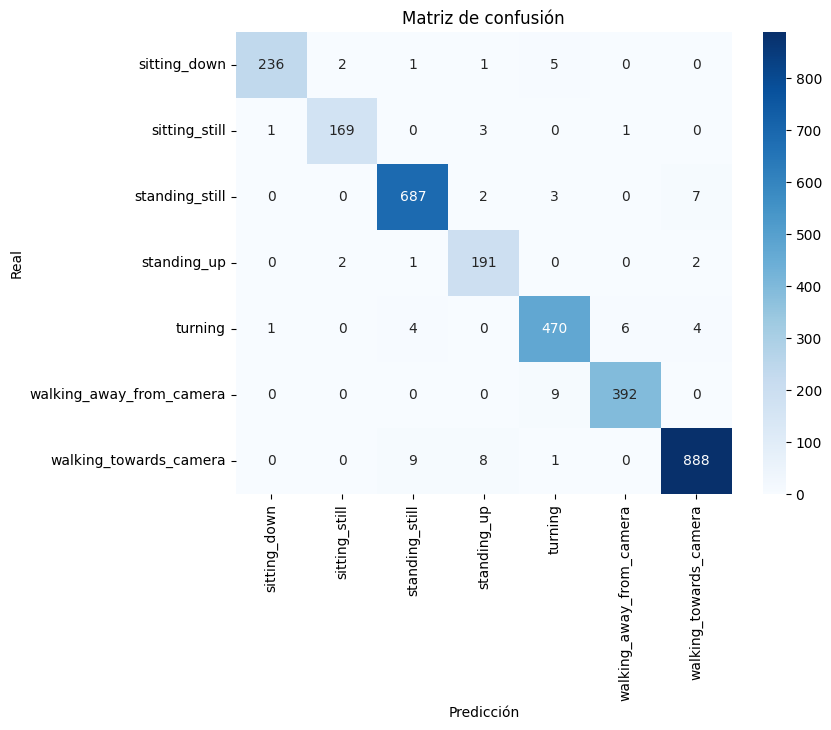

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()


## **Guardar modelo, scaler y label_encoder**

In [ ]:
joblib.dump(model, "best_xgboost_v2.joblib")
joblib.dump(scaler, "scaler_v2.joblib")
joblib.dump(label_encoder, "label_encoder_v2.joblib")

print("Artefactos guardados:")
print(" - best_xgboost_v2.joblib")
print(" - scaler_v2.joblib")
print(" - label_encoder_v2.joblib")

from google.colab import files
files.download("best_xgboost_v2.joblib")
files.download("scaler_v2.joblib")
files.download("label_encoder_v2.joblib")

Artefactos guardados:
 - best_xgboost_v2.joblib
 - scaler_v2.joblib
 - label_encoder_v2.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>